/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


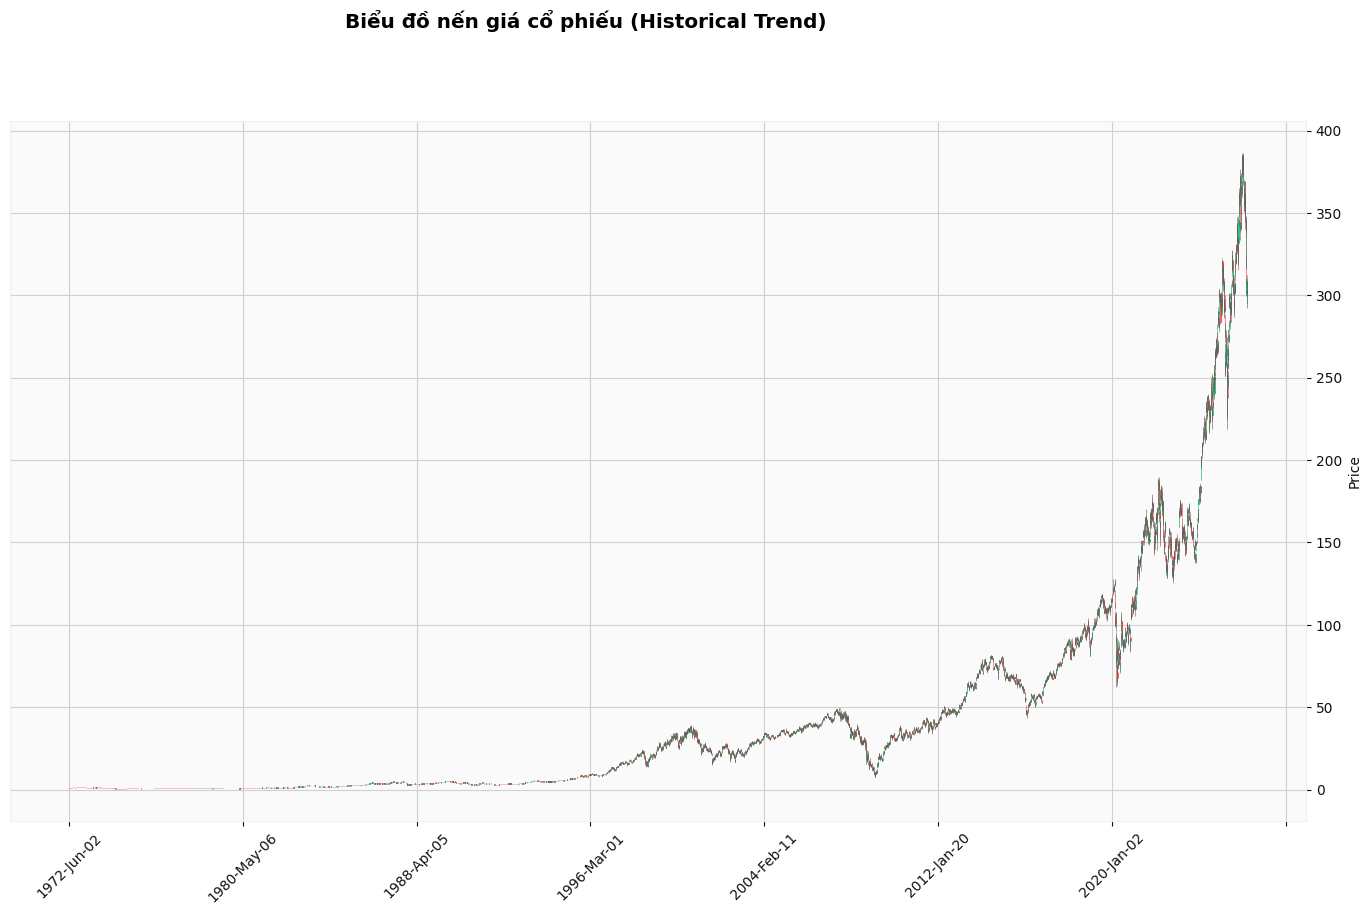

In [ ]:
import mplfinance as mpf
df_ohlc = df[['Open', 'High', 'Low', 'Close']].copy()
# Vẽ biểu đồ nến
fig, axes = mpf.plot(df_ohlc,
                     type='candle',
                     style='yahoo',
                     title='Biểu đồ nến giá cổ phiếu (Historical Trend)',
                     ylabel='Price',
                     returnfig=True,
                     figscale=1.5)
fig.set_size_inches(18, 10)
plt.show()

### Phân tích phân phối Log Return

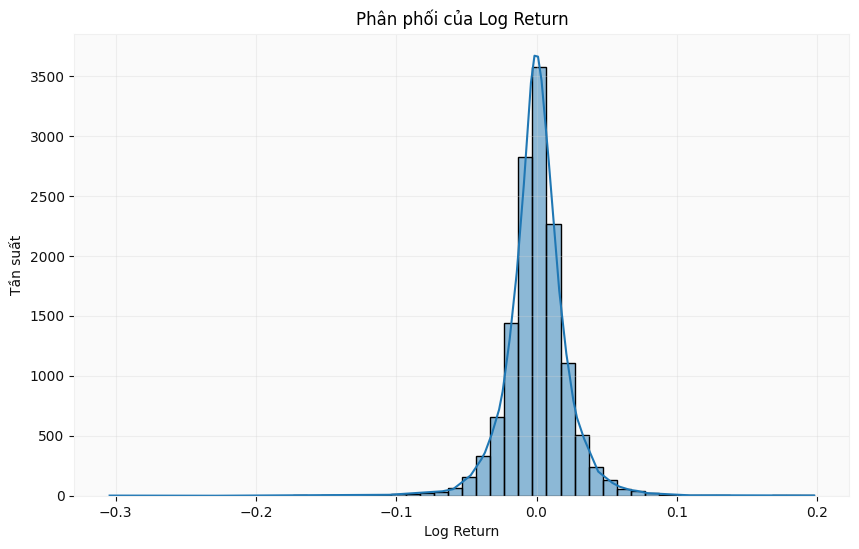

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['Log_Return'], bins=50, kde=True)
plt.title('Phân phối của Log Return')
plt.xlabel('Log Return')
plt.ylabel('Tần suất')
plt.grid(True, alpha=0.3)
plt.show()

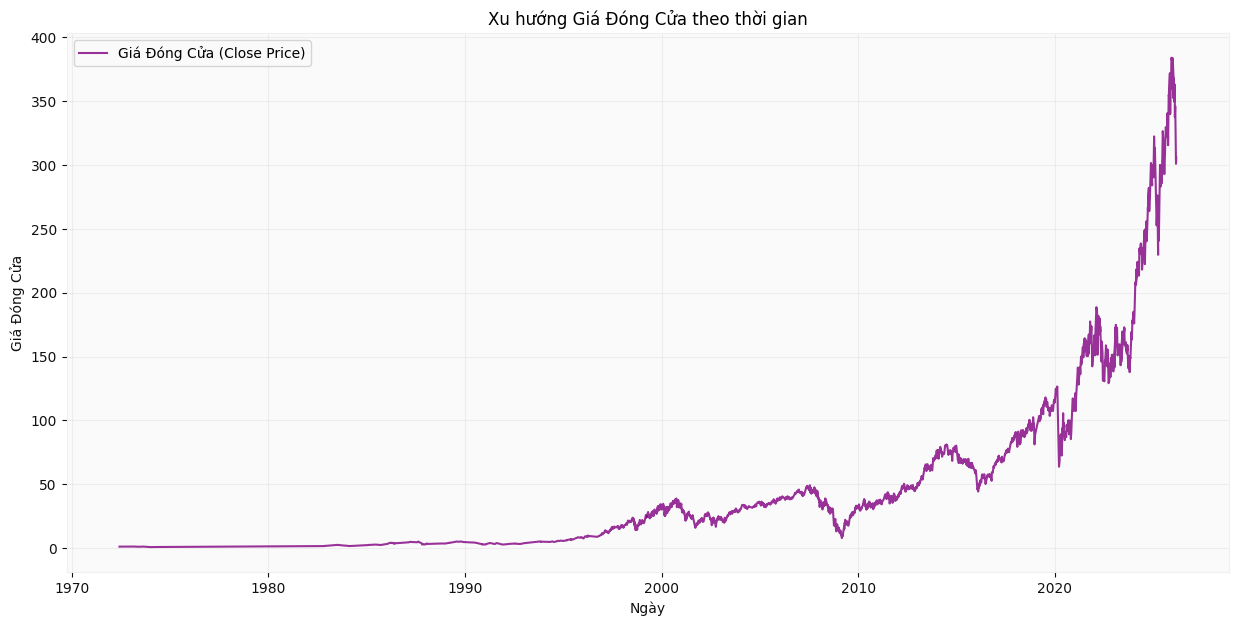

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Close'], label='Giá Đóng Cửa (Close Price)', color='purple', alpha=0.8)
plt.title('Xu hướng Giá Đóng Cửa theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Giá Đóng Cửa')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

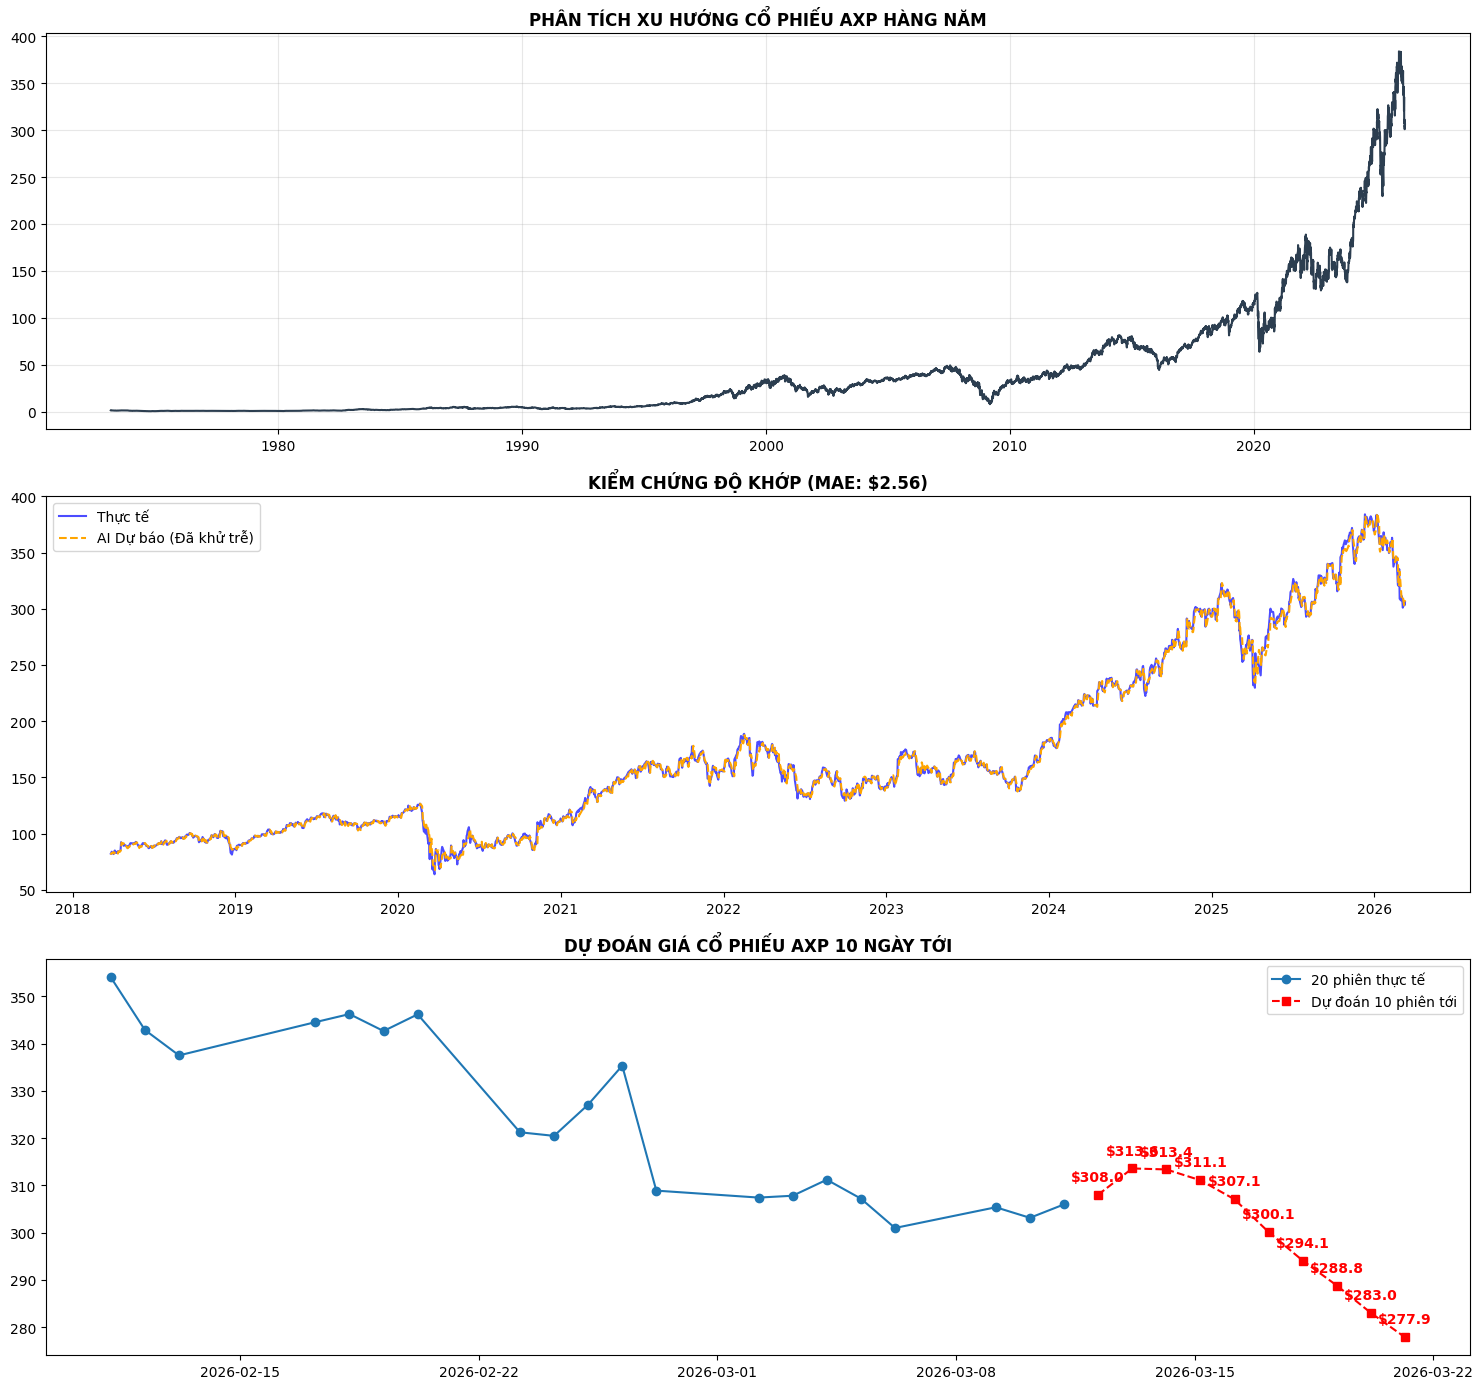


R2: 0.9975 | MAE: $2.56 | MSE: 15.0493
-----------------------------------------------------------------
Thứ 5        | 12/03/2026   | $    308.04
Thứ 6        | 13/03/2026   | $    313.59
Thứ 7        | 14/03/2026   | $    313.38
Chủ Nhật     | 15/03/2026   | $    311.09
Thứ 2        | 16/03/2026   | $    307.06
Thứ 3        | 17/03/2026   | $    300.14
Thứ 4        | 18/03/2026   | $    294.10
Thứ 5        | 19/03/2026   | $    288.83
Thứ 6        | 20/03/2026   | $    283.04
Thứ 7        | 21/03/2026   | $    277.88


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, GRU, Dense, Dropout, concatenate, BatchNormalization, GlobalAveragePooling1D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# 1. TIỀN XỬ LÝ: ROI & ANOMALY SENSITIVITY (THEO FINENET)
df = pd.read_csv('final_stock_prices.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
# ROI và Anomaly
df['ROI'] = np.log1p(df['Close'].pct_change())
mu, sigma, k = df['ROI'].mean(), df['ROI'].std(), 1.0
df['Is_Anomaly'] = ((df['ROI'] >= mu + k*sigma) | (df['ROI'] <= mu - k*sigma)).astype(int)

# Thêm RSI & Stoch
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))
df['Vol_Shock'] = df['Volume'].pct_change()
# Replace infinite values with NaN before dropping them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 2. CHUẨN HÓA & DATASET (LOOK-BACK 45 PHIÊN)
features = ['ROI', 'Is_Anomaly', 'RSI', 'Vol_Shock']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features].values).astype('float32')
look_back = 45
X = np.array([scaled_data[i:i+look_back] for i in range(len(scaled_data)-look_back)])
y = scaled_data[look_back:, 0]
split = int(0.85 * len(X))
XT, Xt, yT, yt = X[:split], X[split:], y[:split], y[split:]

# 3. KIẾN TRÚC FINENET NÂNG CAO (DILATED CNN + GRU) [cite: 44, 53]
inputs = Input(shape=(look_back, len(features)))
# Nhánh CNN bắt đặc trưng ngắn hạn [cite: 54, 69]
c1 = Conv1D(64, 3, activation='relu', padding='same')(inputs)
c1 = BatchNormalization()(c1)
# Nhánh Dilated CNN bắt nhịp tin tức/chu kỳ dài hạn [cite: 55, 70]
c2 = Conv1D(64, 3, dilation_rate=2, activation='relu', padding='same')(inputs)
c2 = BatchNormalization()(c2)
# Nhánh Dilated CNN sâu hơn [cite: 80]
c3 = Conv1D(64, 3, dilation_rate=4, activation='relu', padding='same')(inputs)
c3 = BatchNormalization()(c3)
merged = concatenate([c1, c2, c3])
# GRU tinh lọc đặc trưng tuần tự [cite: 56, 72]
gru = GRU(128, return_sequences=True)(merged)
gru = Dropout(0.4)(gru)
gru = GRU(64)(gru)
outputs = Dense(1, activation='linear')(gru)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss='huber')
model.fit(XT, yT, epochs=20, batch_size=64, validation_split=0.1, verbose=0)
y_p_roi = model.predict(Xt, verbose=0).flatten() * scaler.scale_[0] + scaler.mean_[0]
y_actual = df['Close'].values[split+look_back:]
y_prev = df['Close'].values[split+look_back-1:-1]
y_backtest = y_prev * np.exp(y_p_roi)
# 5. DỰ BÁO 10 NGÀY TƯƠNG LAI
future_prices = []
curr_p = df['Close'].iloc[-1]
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=10)
last_batch = scaled_data[-look_back:].reshape((1, look_back, len(features)))
for _ in range(10):
    p_s = model.predict(last_batch, verbose=0)[0][0]
    p_roi = p_s * scaler.scale_[0] + scaler.mean_[0]
    curr_p *= np.exp(p_roi)
    future_prices.append(curr_p)
    # Cập nhật nhịp sóng kỹ thuật
    new_entry = np.array([[p_s, 0, 50, 0]]).reshape(1,1,len(features))
    last_batch = np.append(last_batch[:, 1:, :], new_entry, axis=1)
plt.figure(figsize=(15, 14))
# Chart: Xu hướng hàng năm [cite: 99]
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], color='#2c3e50', label='Giá hàng năm')
plt.title('PHÂN TÍCH XU HƯỚNG CỔ PHIẾU AXP HÀNG NĂM', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.subplot(3, 1, 2)
plt.plot(df.index[split+look_back:], y_actual, label='Thực tế', color='blue', alpha=0.7)
plt.plot(df.index[split+look_back:], y_backtest, label='AI Dự báo (Đã khử trễ)', color='orange', ls='--')
plt.title(f'KIỂM CHỨNG ĐỘ KHỚP (MAE: ${mean_absolute_error(y_actual, y_backtest):.2f})', fontweight='bold')
plt.legend()

# Chart: Dự báo tương lai 10 ngày [cite: 101, 102]
ax3 = plt.subplot(3, 1, 3)
plt.plot(df.index[-20:], df['Close'][-20:], marker='o', label='20 phiên thực tế')
plt.plot(future_dates, future_prices, marker='s', ls='--', label='Dự đoán 10 phiên tới', color='red')
for d, p in zip(future_dates, future_prices):
    ax3.annotate(f'${p:.1f}', (d, p), xytext=(0,10), textcoords='offset points', ha='center', color='red', fontweight='bold')
plt.title('DỰ ĐOÁN GIÁ CỔ PHIẾU AXP 10 NGÀY TỚI', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
# BÁO CÁO CHI TIẾT
print(f"\nR2: {r2_score(y_actual, y_backtest):.4f} | MAE: ${mean_absolute_error(y_actual, y_backtest):.2f} | MSE: {mean_squared_error(y_actual, y_backtest):.4f}")
print("-" * 65)
for d, p in zip(future_dates, future_prices):
    day_vn = d.strftime('%A').replace('Monday','Thứ 2').replace('Tuesday','Thứ 3').replace('Wednesday','Thứ 4').replace('Thursday','Thứ 5').replace('Friday','Thứ 6').replace('Saturday','Thứ 7').replace('Sunday','Chủ Nhật')
    print(f"{day_vn:<12} | {d.strftime('%d/%m/%Y'):<12} | ${p:>10.2f}")